# Paso 1: Conexión con Mongo Atlas

In [4]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, regexp_extract, when, lit

# Cambiamos .get_session() por .getOrCreate()
spark = SparkSession.builder \
    .appName("EDA_Mascotas") \
    .config("spark.mongodb.read.connection.uri", "mongodb+srv://BD:xxxxcluster0.kthdyh1.mongodb.net/?retryWrites=true&w=majority") \
    .config("spark.jars.packages", "org.mongodb.spark:mongo-spark-connector_2.12:10.1.1") \
    #.getOrCreate() # <--- Línea corregida get_session() es solo si ya se ha iniciado una sesión previa

# Carga de datos crudos desde Atlas
df_raw = spark.read.format("mongodb") \
    .option("database", "ProyectoSemana9") \
    .option("collection", "Mercado_Mascotas_Raw") \
    .load()

## Si trae los datos, cuento el número de registros

In [6]:
print(df_raw.count())

3182


## Muestra los precios y moneda de los primero 10 registros

In [7]:
df_raw.select("precio_raw", "moneda").show(10)

+----------+------+
|precio_raw|moneda|
+----------+------+
|     19.99|  NULL|
|     29.69|  NULL|
|     18.99|  NULL|
|     30.19|  NULL|
|     41.99|  NULL|
|     27.49|  NULL|
|      2.99|  NULL|
|     29.19|  NULL|
|     55.69|  NULL|
|     27.59|  NULL|
+----------+------+
only showing top 10 rows



## Cuento los datos extraidos por tienda

In [9]:
df_raw.groupBy("tienda").count().show()

+-----------+-----+
|     tienda|count|
+-----------+-----+
|    Zooplus|    6|
|     Bitiba|  864|
|Superzoo_CL|  120|
|Tiendanimal|  930|
|     Kiwoko|  900|
|     Amazon|  362|
+-----------+-----+



# Paso 2: Limpieza y Arreglo de Inconsistencias
## 1. Eliminación de Duplicados e Incompletos

In [12]:
# Quitar registros exactamente iguales y aquellos sin nombre o precio
df_clean = df_raw.dropDuplicates(["sku_id", "tienda"]) \
    .filter(col("sku_id").isNotNull()) \
    .filter(col("precio_raw") != "0.0")
print(df_clean.count())

99


In [18]:
df_raw.select("tienda", "formato_raw", "precio_raw","sku_id").show(10, truncate=False)

+-----------+-----------------------------+----------+----------+
|tienda     |formato_raw                  |precio_raw|sku_id    |
+-----------+-----------------------------+----------+----------+
|Tiendanimal|5.15€ el kg\nDesde 5.15€ / kg|19.99     |Sin nombre|
|Tiendanimal|5.55€ el kg\nDesde 5.55€ / kg|29.69     |Sin nombre|
|Tiendanimal|4.43€ el kg\nDesde 4.43€ / kg|18.99     |Sin nombre|
|Tiendanimal|6.86€ el kg\nDesde 6.86€ / kg|30.19     |Sin nombre|
|Tiendanimal|9.02€ el kg\nDesde 9.02€ / kg|41.99     |Sin nombre|
|Tiendanimal|6.29€ el kg\nDesde 6.29€ / kg|27.49     |Sin nombre|
|Tiendanimal|4.98€ el kg\nDesde 4.98€ / kg|2.99      |Sin nombre|
|Tiendanimal|6.21€ el kg\nDesde 6.21€ / kg|29.19     |Sin nombre|
|Tiendanimal|7.51€ el kg\nDesde 7.51€ / kg|55.69     |Sin nombre|
|Tiendanimal|6.12€ el kg\nDesde 6.12€ / kg|27.59     |Sin nombre|
+-----------+-----------------------------+----------+----------+
only showing top 10 rows



In [20]:
from pyspark.sql.functions import col

# Reparamos la columna sku_id usando el texto de formato_raw
df_clean = df_clean.withColumn("sku_id", col("formato_raw"))
df_clean.select("tienda", "formato_raw", "precio_raw","sku_id").show(10, truncate=False)

+-----------+-----------------------------+----------+-----------------------------+
|tienda     |formato_raw                  |precio_raw|sku_id                       |
+-----------+-----------------------------+----------+-----------------------------+
|Tiendanimal|5.15€ el kg\nDesde 5.15€ / kg|19.99     |5.15€ el kg\nDesde 5.15€ / kg|
|Tiendanimal|5.55€ el kg\nDesde 5.55€ / kg|29.69     |5.55€ el kg\nDesde 5.55€ / kg|
|Tiendanimal|4.43€ el kg\nDesde 4.43€ / kg|18.99     |4.43€ el kg\nDesde 4.43€ / kg|
|Tiendanimal|6.86€ el kg\nDesde 6.86€ / kg|30.19     |6.86€ el kg\nDesde 6.86€ / kg|
|Tiendanimal|9.02€ el kg\nDesde 9.02€ / kg|41.99     |9.02€ el kg\nDesde 9.02€ / kg|
|Tiendanimal|6.29€ el kg\nDesde 6.29€ / kg|27.49     |6.29€ el kg\nDesde 6.29€ / kg|
|Tiendanimal|4.98€ el kg\nDesde 4.98€ / kg|2.99      |4.98€ el kg\nDesde 4.98€ / kg|
|Tiendanimal|6.21€ el kg\nDesde 6.21€ / kg|29.19     |6.21€ el kg\nDesde 6.21€ / kg|
|Tiendanimal|7.51€ el kg\nDesde 7.51€ / kg|55.69     |7.51€ el kg

## 2. Normalización de Precios (CLP a EUR)

In [21]:
# Convertimos el precio a numérico y normalizamos a una sola moneda (EUR)
df_clean = df_raw.withColumn("precio_num", col("precio_raw").cast("double"))

df_clean = df_clean.withColumn("precio_eur", 
    when(col("moneda") == "CLP", col("precio_num") / 980)
    .otherwise(col("precio_num"))
)

## 3. Extracción de Peso (Bioingeniería de Variables)

In [22]:
from pyspark.sql.functions import col, regexp_extract, regexp_replace, when

# 1. Extraemos el número y la unidad
# 2. Usamos regexp_replace para cambiar la coma por punto ANTES del cast
df_clean = df_clean.withColumn("peso_kg", 
    regexp_replace(
        regexp_extract(col("formato_raw"), r"(\d+[.,]?\d*)\s*(?i)(kg|g|gr)", 1), 
        ",", "."
    ).cast("double")
)

# 3. Normalización: Si el peso se extrajo en gramos, lo pasamos a KG
df_clean = df_clean.withColumn("peso_kg",
    when(
        (col("formato_raw").contains("g") | col("formato_raw").contains("gr")) & 
        ~col("formato_raw").contains("kg"), 
        col("peso_kg") / 1000
    ).otherwise(col("peso_kg"))
)

In [23]:
from pyspark.sql.functions import col

# Seleccionamos una muestra significativa que incluya casos con comas y diferentes unidades
print("--- COMPARATIVA DE TRANSFORMACIÓN DE DATOS ---")
df_clean.select(
    col("formato_raw").alias("Original (Texto)"),
    col("peso_kg").alias("Limpio (Peso KG)"),
    col("precio_raw").alias("Original (Precio)"),
    col("precio_eur").alias("Limpio (Precio EUR)")
).show(15, truncate=False)

--- COMPARATIVA DE TRANSFORMACIÓN DE DATOS ---
+-----------------------------+----------------+-----------------+-------------------+
|Original (Texto)             |Limpio (Peso KG)|Original (Precio)|Limpio (Precio EUR)|
+-----------------------------+----------------+-----------------+-------------------+
|5.15€ el kg\nDesde 5.15€ / kg|NULL            |19.99            |19.99              |
|5.55€ el kg\nDesde 5.55€ / kg|NULL            |29.69            |29.69              |
|4.43€ el kg\nDesde 4.43€ / kg|NULL            |18.99            |18.99              |
|6.86€ el kg\nDesde 6.86€ / kg|NULL            |30.19            |30.19              |
|9.02€ el kg\nDesde 9.02€ / kg|NULL            |41.99            |41.99              |
|6.29€ el kg\nDesde 6.29€ / kg|NULL            |27.49            |27.49              |
|4.98€ el kg\nDesde 4.98€ / kg|NULL            |2.99             |2.99               |
|6.21€ el kg\nDesde 6.21€ / kg|NULL            |29.19            |29.19            

# Paso 3: Análisis Exploratorio de Datos (EDA) con Spark

## 1. Análisis Descriptivo (Estadísticas básicas)

In [24]:
# Resumen de variables numéricas (Precio y Peso)
df_clean.select("precio_eur", "peso_kg", "rating").describe().show()

+-------+------------------+------------------+-----------------+
|summary|        precio_eur|           peso_kg|           rating|
+-------+------------------+------------------+-----------------+
|  count|              2237|              1134|             3062|
|   mean|19.380527857097306| 9.350803703703702|4.655127367733527|
| stddev|16.334057604111077|24.271348232079752| 0.65022160932796|
|    min|               0.0|            0.0024|                0|
|    max|107.13265306122449|             700.0|              5.0|
+-------+------------------+------------------+-----------------+



## 2. Análisis de Valores Faltantes (Nulos)

In [26]:
from pyspark.sql.functions import count, isnan

df_clean.select([count(when(isnan(c) | col(c).isNull(), c)).alias(c) for c in df_clean.columns]).show()

+---+-------------+-----------+-----+-----+------+---------+----------+------+------+------+----------+----------+-------+
|_id|fecha_captura|formato_raw|grupo|marca|moneda|opiniones|precio_raw|rating|sku_id|tienda|precio_num|precio_eur|peso_kg|
+---+-------------+-----------+-----+-----+------+---------+----------+------+------+------+----------+----------+-------+
|  0|            0|          0| 2820|    0|  3062|      120|         0|   120|     0|     0|       945|       945|   2048|
+---+-------------+-----------+-----+-----+------+---------+----------+------+------+------+----------+----------+-------+



## 3. Análisis por Grupos (Marcas y Tiendas)

In [27]:
df_clean.withColumn("precio_por_kilo", col("precio_eur") / col("peso_kg")) \
    .groupBy("marca") \
    .avg("precio_por_kilo") \
    .orderBy("avg(precio_por_kilo)", ascending=False).show()

+------------------+--------------------+
|             marca|avg(precio_por_kilo)|
+------------------+--------------------+
|   Pendiente_Spark|   2.720408163265305|
|   Amazon_Mascotas|                 0.0|
|Zooplus_Veterinary|                NULL|
| Bitiba_Veterinary|                NULL|
|               S/M|                NULL|
+------------------+--------------------+



# Paso 4: Visualización

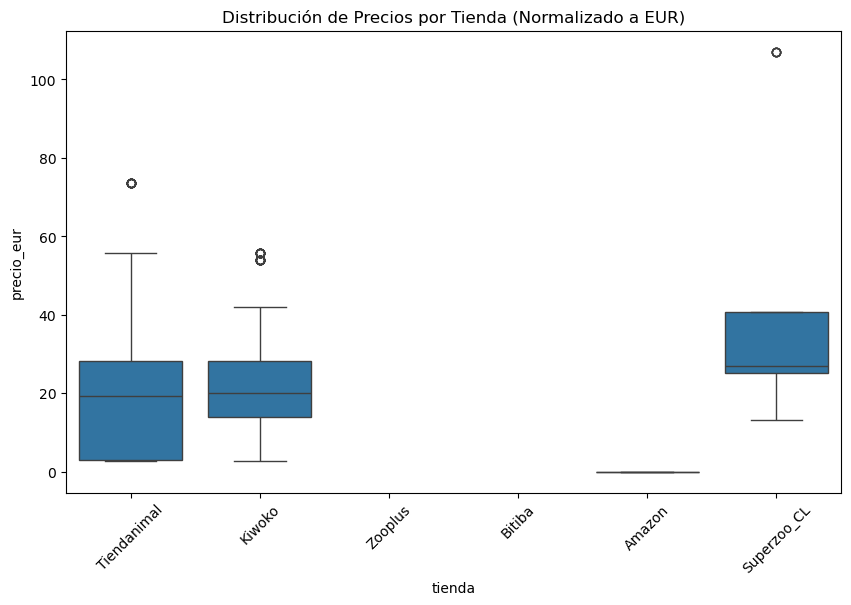

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# Convertimos una muestra a Pandas para graficar
pdf = df_clean.sample(False, 0.5).toPandas()

plt.figure(figsize=(10,6))
sns.boxplot(x='tienda', y='precio_eur', data=pdf)
plt.title("Distribución de Precios por Tienda (Normalizado a EUR)")
plt.xticks(rotation=45)
plt.show()